# Error bars on an optimal design

Kinetic parameters come from noisy data, so they have error bars. A reactor
design optimized with those parameters inherits them. This notebook puts a
confidence region on a *design* — not on a fit — by chaining two things POUNCE
reads off held KKT factorizations:

* $\Sigma_\theta$, the covariance of the fitted kinetics, from `sens_covariance`
  (notebooks 26 / 31 / 32);
* $J = \partial x^\star/\partial\theta$, how the optimizer's answer moves with a
  parameter, from `sens_jacobian` (notebooks 04 / 25 / 36).

The delta method joins them:

$$\operatorname{Var}(x^\star) \;=\; J\,\Sigma_\theta\,J^{\mathsf T},
\qquad
\operatorname{Var}(f^\star) \;=\; g^{\mathsf T}\Sigma_\theta\, g,
\qquad g_i = \frac{\mathrm d f^\star}{\mathrm d \theta_i}.$$

$J$ exists only because $x^\star(\theta)$ is defined *implicitly*, by the KKT
system rather than by a formula — the implicit function theorem doing the work.
It is an exact first-order derivative from one backsolve per parameter, not a
finite difference, and it costs no re-solve.

**The result worth reading for.** Fitted Arrhenius parameters are almost
perfectly correlated: $\ln A$ and $E$ trade off along a line that holds the rate
constant fixed over the temperature window the data actually cover. Propagating
only the standard errors — the diagonal of $\Sigma_\theta$, which is what you
have if each parameter was reported with a $\pm$ and nothing else — throws that
correlation away and **overstates the uncertainty in the optimal profit by a
factor of 57**. The design is far better determined than its parameters are.

The last sections are about where this stops working: an active constraint makes
$x^\star(\theta)$ non-differentiable, the Gaussian ellipse becomes a lie, and
POUNCE can say so from the base factorization before you spend a single
re-solve finding out.

In [1]:
import itertools, platform, subprocess
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pyomo.environ as pyo
import pyomo_pounce
from pyomo_pounce import (
    declare_sens_fitted, declare_sens_residual, declare_sens_param,
    sens_covariance, sens_jacobian, sens_solution_report,
    sens_active_set_changes, sens_release_kkt,
)

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"pyomo-pounce  {meta.version('pyomo-pounce')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
SOLVER = pyo.SolverFactory("pounce")

python        3.12.11
pounce-solver 0.11.0
pyomo-pounce  0.1.0
commit        91de7070f800


## 1. The chemistry, and some data

One feed species reacts down two competing paths,

$$\mathrm{A}\xrightarrow{\;k_1\;}\mathrm{B}\ \text{(product)},
\qquad
\mathrm{A}\xrightarrow{\;k_2\;}\mathrm{C}\ \text{(waste)},$$

both first order in $\mathrm A$, both Arrhenius. We fit $\ln A$ rather than $A$
so that the two parameters of a pair are comparably scaled, and we work in
kJ/mol:

$$k_j(T) = \exp\!\left(\ln A_j - \frac{E_j}{RT}\right).$$

The waste path has the **larger** activation energy ($E_2 > E_1$), so heating
the reactor speeds up the reaction you do not want more than the one you do.
That is the design tension in one line: temperature buys conversion and costs
selectivity.

The data are isothermal batch runs — four temperatures, four sampling times,
$\mathrm A$ and $\mathrm B$ each measured with independent Gaussian noise. For a
batch reactor the concentrations are closed form, which keeps the estimation
problem algebraic and small:

$$C_A = C_{A0}e^{-Kt},\qquad
C_B = C_{A0}\frac{k_1}{K}\left(1-e^{-Kt}\right),\qquad K = k_1+k_2 .$$

In [2]:
R    = 0.008314          # kJ / mol / K
CA0  = 1.0               # mol / L
THETA_NAMES = ["lnA1", "E1", "lnA2", "E2"]
THETA_TRUE  = np.array([18.23, 60.0, 23.70, 80.0])   # E in kJ/mol
NOISE = 0.01             # mol / L, measurement standard deviation

T_RUNS  = [325.0, 335.0, 345.0, 355.0]
T_TIMES = [10.0, 30.0, 60.0, 120.0]


def rate_constants(T, theta):
    """k1, k2 at temperature T."""
    lnA1, E1, lnA2, E2 = theta
    return np.exp(lnA1 - E1 / (R * T)), np.exp(lnA2 - E2 / (R * T))


def batch_profile(T, t, theta):
    """Closed-form CA, CB for the isothermal batch reactor."""
    k1, k2 = rate_constants(T, theta)
    K = k1 + k2
    return CA0 * np.exp(-K * t), CA0 * k1 / K * (1.0 - np.exp(-K * t))


rng  = np.random.default_rng(0)
DATA = []                                   # (T, t, CA_obs, CB_obs)
for T in T_RUNS:
    for t in T_TIMES:
        ca, cb = batch_profile(T, t, THETA_TRUE)
        DATA.append((T, t, ca + rng.normal(0, NOISE), cb + rng.normal(0, NOISE)))

print(f"{len(DATA)} sampling points, {2 * len(DATA)} measurements, 4 parameters")

16 sampling points, 32 measurements, 4 parameters


## 2. Fit the kinetics

An ordinary least-squares NLP. Two declarations are all the sensitivity layer
needs: `declare_sens_fitted` names the parameters being estimated (they stay
free variables), and `declare_sens_residual` names the container the residuals
live in, from which the noise variance is estimated — the count and the sum of
squares are both derived from it, nothing is passed by hand.

In [3]:
def build_fit_model(data):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(data) - 1)

    # deliberately crude starting values -- nothing is seeded with the truth
    m.lnA1 = pyo.Var(initialize=17.0)
    m.E1   = pyo.Var(initialize=55.0)
    m.lnA2 = pyo.Var(initialize=22.0)
    m.E2   = pyo.Var(initialize=75.0)
    m.rA   = pyo.Var(m.I, initialize=0.0)
    m.rB   = pyo.Var(m.I, initialize=0.0)

    def k1(m, i): return pyo.exp(m.lnA1 - m.E1 / (R * data[i][0]))
    def k2(m, i): return pyo.exp(m.lnA2 - m.E2 / (R * data[i][0]))

    def res_A(m, i):
        K = k1(m, i) + k2(m, i)
        return m.rA[i] == CA0 * pyo.exp(-K * data[i][1]) - data[i][2]

    def res_B(m, i):
        K = k1(m, i) + k2(m, i)
        return m.rB[i] == (CA0 * k1(m, i) / K
                           * (1 - pyo.exp(-K * data[i][1]))) - data[i][3]

    m.cA  = pyo.Constraint(m.I, rule=res_A)
    m.cB  = pyo.Constraint(m.I, rule=res_B)
    m.obj = pyo.Objective(expr=sum(m.rA[i]**2 + m.rB[i]**2 for i in m.I),
                          sense=pyo.minimize)
    return m


m_fit = build_fit_model(DATA)
declare_sens_fitted(m_fit.lnA1, m_fit.E1, m_fit.lnA2, m_fit.E2)
declare_sens_residual(m_fit.rA, m_fit.rB)
SOLVER.solve(m_fit)

FITTED_VARS = [m_fit.lnA1, m_fit.E1, m_fit.lnA2, m_fit.E2]
THETA_HAT   = np.array([pyo.value(v) for v in FITTED_VARS])

print(f"{'':7s}{'fitted':>10s}{'true':>10s}")
for n, hat, true in zip(THETA_NAMES, THETA_HAT, THETA_TRUE):
    print(f"{n:7s}{hat:10.3f}{true:10.3f}")

           fitted      true
lnA1       18.166    18.230
E1         59.812    60.000
lnA2       23.853    23.700
E2         80.453    80.000


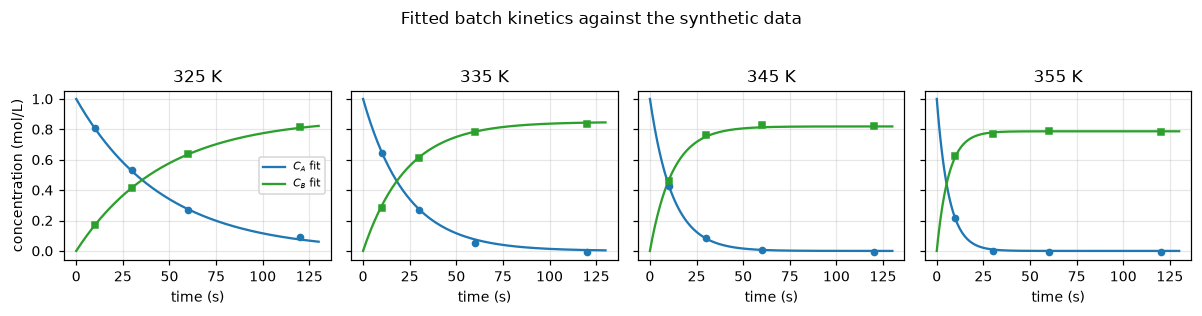

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.7), sharey=True)
tt = np.linspace(0, 130, 200)
for ax, T in zip(axes, T_RUNS):
    pts = [d for d in DATA if d[0] == T]
    ca, cb = batch_profile(T, tt, THETA_HAT)
    ax.plot(tt, ca, color="C0", label=r"$C_A$ fit")
    ax.plot(tt, cb, color="C2", label=r"$C_B$ fit")
    ax.plot([p[1] for p in pts], [p[2] for p in pts], "o", ms=4, color="C0")
    ax.plot([p[1] for p in pts], [p[3] for p in pts], "s", ms=4, color="C2")
    ax.set_title(f"{T:.0f} K"); ax.set_xlabel("time (s)")
axes[0].set_ylabel("concentration (mol/L)")
axes[0].legend(fontsize=7, loc="center right")
fig.suptitle("Fitted batch kinetics against the synthetic data", y=1.04)
fig.tight_layout(); plt.show()

## 3. The covariance, and the compensation effect

`sens_covariance(m_fit)` reads the asymptotic covariance off the same
factorization the solve already built. The standard errors are unremarkable.
The **correlation matrix** is the point of this section.

In [5]:
cov   = sens_covariance(m_fit)
SIGMA = np.array([[cov[a, b] for b in FITTED_VARS] for a in FITTED_VARS])
sd    = np.sqrt(np.diag(SIGMA))
corr  = SIGMA / np.outer(sd, sd)

print(f"estimated noise variance {cov.sigma_sq:.3e}   (true {NOISE**2:.3e})\n")
print(f"{'':7s}{'value':>10s}{'std err':>10s}")
for n, v, s in zip(THETA_NAMES, THETA_HAT, sd):
    print(f"{n:7s}{v:10.3f}{s:10.3f}")

print("\ncorrelation")
print(f"{'':7s}" + "".join(f"{n:>9s}" for n in THETA_NAMES))
for i, n in enumerate(THETA_NAMES):
    print(f"{n:7s}" + "".join(f"{corr[i, j]:9.4f}" for j in range(4)))

estimated noise variance 7.415e-05   (true 1.000e-04)

            value   std err
lnA1       18.166     0.237
E1         59.812     0.661
lnA2       23.853     0.739
E2         80.453     2.119

correlation
            lnA1       E1     lnA2       E2
lnA1      1.0000   0.9995   0.2957   0.2857
E1        0.9995   1.0000   0.2943   0.2846
lnA2      0.2957   0.2943   1.0000   0.9996
E2        0.2857   0.2846   0.9996   1.0000


$\ln A_1$ with $E_1$, and $\ln A_2$ with $E_2$, are correlated at **0.9995 and
above**. This is the Arrhenius compensation effect, and it is not a defect in
the data — it is a statement about what the data can see. Over a temperature
window of 30 K, what the measurements pin down is $k_j(T)$ *inside that window*.
Raising $E_j$ and raising $\ln A_j$ together leaves $k_j$ almost unchanged there,
so the likelihood is nearly flat along that direction and the confidence region
is a long thin sliver rather than a ball.

The two panels below say the same thing twice: an Arrhenius plot, where the
data constrain the *lines* far better than they constrain either intercept or
slope alone, and the 95 % confidence ellipses in each parameter pair.

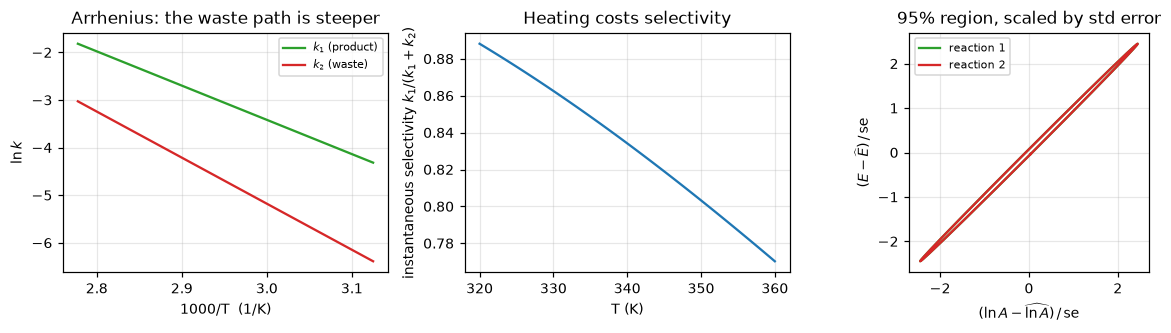

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

# -- Arrhenius lines ------------------------------------------------------
ax = axes[0]
Tg = np.linspace(320, 360, 100)
k1, k2 = rate_constants(Tg, THETA_HAT)
ax.plot(1000 / Tg, np.log(k1), color="C2", label=r"$k_1$ (product)")
ax.plot(1000 / Tg, np.log(k2), color="C3", label=r"$k_2$ (waste)")
ax.set_xlabel("1000/T  (1/K)"); ax.set_ylabel(r"$\ln k$")
ax.set_title("Arrhenius: the waste path is steeper"); ax.legend(fontsize=7)

# -- selectivity ----------------------------------------------------------
ax = axes[1]
ax.plot(Tg, k1 / (k1 + k2), color="C0")
ax.set_xlabel("T (K)"); ax.set_ylabel(r"instantaneous selectivity $k_1/(k_1+k_2)$")
ax.set_title("Heating costs selectivity")

# -- confidence ellipses in each pair -------------------------------------
ax = axes[2]
def ellipse_xy(mu, cov2, nsig=2.4477, n=200):        # 2.4477 -> 95% for 2 dof
    w, V = np.linalg.eigh(cov2)
    th = np.linspace(0, 2 * np.pi, n)
    pts = (V * (nsig * np.sqrt(np.maximum(w, 0)))) @ np.array([np.cos(th), np.sin(th)])
    return mu[0] + pts[0], mu[1] + pts[1]

for idx, lab, col in (((0, 1), "reaction 1", "C2"), ((2, 3), "reaction 2", "C3")):
    i, j = idx
    S2 = SIGMA[np.ix_(idx, idx)]
    # centre and scale each pair on its own standard errors so both fit one axes
    x, y = ellipse_xy(np.zeros(2), S2 / np.outer(sd[list(idx)], sd[list(idx)]))
    ax.plot(x, y, color=col, label=lab)
ax.set_xlabel(r"$(\ln A - \widehat{\ln A})\,/\,\mathrm{se}$")
ax.set_ylabel(r"$(E - \widehat{E})\,/\,\mathrm{se}$")
ax.set_title("95% region, scaled by std error"); ax.legend(fontsize=7)
ax.set_aspect("equal")

fig.tight_layout(); plt.show()

The ellipses are almost degenerate — nearly the diagonal line $ \Delta\ln A/\mathrm{se}
= \Delta E/\mathrm{se}$. A box drawn from the standard errors alone would be the
unit square around that sliver: it contains the sliver, but it also contains a
great deal of parameter space the data have firmly ruled out. Section 6 is what
that difference costs.

## 4. The reactor design

A steady-state isothermal CSTR on the same chemistry. Choose the temperature
$T$ and the residence time $\tau$ to maximize profit per litre of feed,

$$\max_{T,\tau}\;\; p_B C_B \;-\; c_T (T - T_0) \;-\; c_\tau \tau,
\qquad
C_B = \frac{C_{A0}\,k_1(T)\,\tau}{1 + \bigl(k_1(T)+k_2(T)\bigr)\tau},$$

a heating cost linear in temperature rise and a reactor-size cost linear in
residence time. Low $T$ means almost no conversion, so $\tau$ must be huge; high
$T$ means the waste path takes over. The optimum is interior in both.

Two modelling choices worth stating, because both are load-bearing:

* **The kinetic parameters enter as mutable `Param`s, each pinned to a `Var` by
  a single defining equality** (`m.a1 == m.lnA1`). `declare_sens_param` will
  rewrite the model itself if you skip this, but it warns when it does; writing
  the pin explicitly is what the docs recommend and it keeps the model yours.
* **The objective is written as a `minimize` of negative profit.** Nothing
  forces that: `sens_jacobian(of=<Objective>)` differentiates the objective *as
  the model states it*, so a `maximize` spelling hands back
  $\mathrm d(\text{profit})/\mathrm d\theta$ with no negation at all. This
  way costs the one `g_prof = -g_obj` in section 5 and buys the convention that
  every printed derivative below is a derivative of the thing being minimized.
  It was load-bearing once — the objective's sense was not carried back across
  the in-process solve, so `df/dp` came back sign-flipped on a `maximize` model
  — and the finite-difference check in section 5 is what catches that class
  either way.

In [7]:
P_B, C_T, C_TAU, T0 = 100.0, 0.4, 0.15, 320.0     # $/mol, $/K, $/s, K


def build_design_model(theta, T_max=400.0):
    m = pyo.ConcreteModel()

    m.lnA1 = pyo.Param(initialize=theta[0], mutable=True)
    m.E1   = pyo.Param(initialize=theta[1], mutable=True)
    m.lnA2 = pyo.Param(initialize=theta[2], mutable=True)
    m.E2   = pyo.Param(initialize=theta[3], mutable=True)

    # one defining equality per parameter: what declare_sens_param wants
    m.a1 = pyo.Var(initialize=theta[0]);  m.e1 = pyo.Var(initialize=theta[1])
    m.a2 = pyo.Var(initialize=theta[2]);  m.e2 = pyo.Var(initialize=theta[3])
    m.pin_a1 = pyo.Constraint(expr=m.a1 == m.lnA1)
    m.pin_e1 = pyo.Constraint(expr=m.e1 == m.E1)
    m.pin_a2 = pyo.Constraint(expr=m.a2 == m.lnA2)
    m.pin_e2 = pyo.Constraint(expr=m.e2 == m.E2)

    m.T   = pyo.Var(bounds=(300.0, T_max), initialize=345.0)
    m.tau = pyo.Var(bounds=(1.0, 300.0),   initialize=68.0)
    m.CB  = pyo.Var(initialize=0.5)

    k1 = pyo.exp(m.a1 - m.e1 / (R * m.T))
    k2 = pyo.exp(m.a2 - m.e2 / (R * m.T))
    m.cstr = pyo.Constraint(expr=m.CB * (1 + (k1 + k2) * m.tau) == CA0 * k1 * m.tau)

    # minimize NEGATIVE profit -- see the note above
    m.obj = pyo.Objective(
        expr=C_T * (m.T - T0) + C_TAU * m.tau - P_B * m.CB, sense=pyo.minimize)
    return m


def solve_design(theta, T_max=400.0):
    """Optimal (T, tau, profit) at these kinetic parameters."""
    m = build_design_model(theta, T_max)
    SOLVER.solve(m)
    return np.array([pyo.value(m.T), pyo.value(m.tau), -pyo.value(m.obj)])


m_des = build_design_model(THETA_HAT)
declare_sens_param(m_des.lnA1, m_des.E1, m_des.lnA2, m_des.E2)
SOLVER.solve(m_des)

DESIGN_PARAMS = [m_des.lnA1, m_des.E1, m_des.lnA2, m_des.E2]
T_STAR, TAU_STAR = pyo.value(m_des.T), pyo.value(m_des.tau)
PROFIT_STAR = -pyo.value(m_des.obj)
k1s, k2s = rate_constants(T_STAR, THETA_HAT)
print(f"T*      = {T_STAR:8.3f} K")
print(f"tau*    = {TAU_STAR:8.3f} s")
print(f"profit* = {PROFIT_STAR:8.3f} $/L")
print(f"selectivity {k1s / (k1s + k2s):.3f}, conversion "
      f"{(k1s + k2s) * TAU_STAR / (1 + (k1s + k2s) * TAU_STAR):.3f}")

T*      =  345.050 K
tau*    =   68.895 s
profit* =   49.401 $/L
selectivity 0.819, conversion 0.852


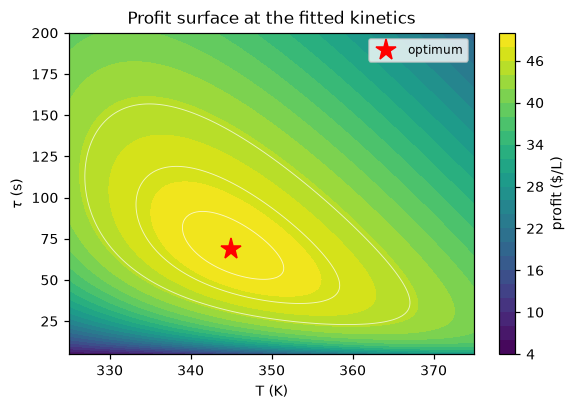

In [8]:
Tg  = np.linspace(325, 375, 160)
tg  = np.linspace(5, 200, 160)
TG, GG = np.meshgrid(Tg, tg, indexing="ij")
k1g, k2g = rate_constants(TG, THETA_HAT)
CBg = CA0 * k1g * GG / (1 + (k1g + k2g) * GG)
PROF = P_B * CBg - C_T * (TG - T0) - C_TAU * GG

fig, ax = plt.subplots(figsize=(5.4, 3.8))
cf = ax.contourf(TG, GG, PROF, levels=24, cmap="viridis")
ax.contour(TG, GG, PROF, levels=[PROFIT_STAR - d for d in (5, 2, 0.5)],
           colors="w", linewidths=0.6, alpha=0.7)
ax.plot(T_STAR, TAU_STAR, "r*", ms=14, label="optimum")
fig.colorbar(cf, ax=ax, label="profit ($/L)")
ax.set_xlabel("T (K)"); ax.set_ylabel(r"$\tau$ (s)")
ax.set_title("Profit surface at the fitted kinetics"); ax.legend(fontsize=8)
ax.grid(False)
fig.tight_layout(); plt.show()

## 5. $J$ and $g$ from one factorization

The design solve is done and its KKT factorization is held. Every derivative
below is a backsolve against that factor — no re-solve, no finite difference.

* `sens_jacobian(m.T, wrt=m.E2)` is $\partial T^\star/\partial E_2$;
* `sens_jacobian(m.obj, wrt=m.E2)` is the **total** derivative
  $\mathrm df^\star/\mathrm dE_2 = \partial f/\partial E_2|_x + \sum_i (\partial
  f/\partial x_i)(\partial x_i/\partial E_2)$. Both halves are included, which
  matters here because the parameters reach the objective only through $C_B$.

`J` is assembled by iterating over one explicit `DESIGN_PARAMS` list, and
$\Sigma$ was assembled from `FITTED_VARS` in the same order. That ordering is
the one thing in this notebook that can go silently wrong: $\Sigma$ is keyed by
Pyomo component data and `J` is a bare array, so nothing would complain if the
columns disagreed. The assertion below is cheap insurance, and the
finite-difference table is the real check.

In [9]:
assert [p.name for p in DESIGN_PARAMS] == [v.name for v in FITTED_VARS] == THETA_NAMES

J = np.array([[sens_jacobian(v, wrt=p) for p in DESIGN_PARAMS]
              for v in (m_des.T, m_des.tau)])
g_obj  = np.array([sens_jacobian(m_des.obj, wrt=p) for p in DESIGN_PARAMS])
g_prof = -g_obj                     # profit = -objective

print(f"{'':7s}{'dT*/dth':>12s}{'dtau*/dth':>12s}{'dprofit/dth':>14s}")
for i, n in enumerate(THETA_NAMES):
    print(f"{n:7s}{J[0, i]:12.4f}{J[1, i]:12.4f}{g_prof[i]:14.4f}")

            dT*/dth   dtau*/dth   dprofit/dth
lnA1        -1.5900    -12.8298       21.0973
E1           1.3866      2.8244       -7.3542
lnA2       -10.0074      7.3326      -10.7630
E2           3.0638     -1.7154        3.7518


In [10]:
# --- verify every derivative against a central finite difference ----------
print(f"{'':7s}{'quantity':>10s}{'sensitivity':>14s}{'finite diff':>14s}{'rel err':>10s}")
for i, n in enumerate(THETA_NAMES):
    h = 1e-4 * max(1.0, abs(THETA_HAT[i]))
    step = np.zeros(4); step[i] = h
    hi, lo = solve_design(THETA_HAT + step), solve_design(THETA_HAT - step)
    fd = (hi - lo) / (2 * h)
    for q, exact, num in (("T*", J[0, i], fd[0]), ("tau*", J[1, i], fd[1]),
                          ("profit*", g_prof[i], fd[2])):
        rel = abs(exact - num) / max(abs(num), 1e-12)
        print(f"{n:7s}{q:>10s}{exact:14.6f}{num:14.6f}{rel:10.2e}")
        assert rel < 1e-4, (n, q)
print("\nall derivatives agree with finite differences")

         quantity   sensitivity   finite diff   rel err


lnA1           T*     -1.590036     -1.590038  1.25e-06
lnA1         tau*    -12.829826    -12.829810  1.19e-06
lnA1      profit*     21.097270     21.097268  8.33e-08


E1             T*      1.386642      1.386642  5.26e-07
E1           tau*      2.824411      2.824406  1.93e-06
E1        profit*     -7.354181     -7.354181  1.06e-07


lnA2           T*    -10.007371    -10.007369  2.00e-07
lnA2         tau*      7.332586      7.332575  1.45e-06
lnA2      profit*    -10.762952    -10.762951  1.05e-07


E2             T*      3.063769      3.063768  1.82e-07
E2           tau*     -1.715352     -1.715348  2.61e-06
E2        profit*      3.751798      3.751798  3.43e-08

all derivatives agree with finite differences


## 6. Propagate

$\operatorname{Var}(x^\star) = J\,\Sigma\,J^{\mathsf T}$ with the full
$\Sigma$, and — for contrast — the same expression with everything off the
diagonal deleted, which is the calculation you are implicitly doing whenever you
carry parameters around as independent $\pm$ values.

In [11]:
SIGMA_DIAG = np.diag(np.diag(SIGMA))

cov_full = J @ SIGMA      @ J.T
cov_diag = J @ SIGMA_DIAG @ J.T
sd_profit_full = float(np.sqrt(g_prof @ SIGMA      @ g_prof))
sd_profit_diag = float(np.sqrt(g_prof @ SIGMA_DIAG @ g_prof))

print(f"{'':22s}{'full Sigma':>14s}{'diagonal only':>16s}{'ratio':>9s}")
for lbl, i in (("sd(T*)      [K]", 0), ("sd(tau*)    [s]", 1)):
    f, d = np.sqrt(cov_full[i, i]), np.sqrt(cov_diag[i, i])
    print(f"{lbl:22s}{f:14.3f}{d:16.3f}{d / f:8.1f}x")
print(f"{'sd(profit)  [$/L]':22s}{sd_profit_full:14.4f}{sd_profit_diag:16.4f}"
      f"{sd_profit_diag / sd_profit_full:8.1f}x")

rho = cov_full[0, 1] / np.sqrt(cov_full[0, 0] * cov_full[1, 1])
print(f"\ncorr(T*, tau*) = {rho:+.3f}")
print(f"\nT*      = {T_STAR:.2f} +/- {np.sqrt(cov_full[0, 0]):.2f} K")
print(f"tau*    = {TAU_STAR:.2f} +/- {np.sqrt(cov_full[1, 1]):.2f} s")
print(f"profit* = {PROFIT_STAR:.2f} +/- {sd_profit_full:.2f} $/L")

                          full Sigma   diagonal only    ratio
sd(T*)      [K]                0.888           9.888    11.1x
sd(tau*)    [s]                1.799           7.435     4.1x
sd(profit)  [$/L]             0.2340         13.2296    56.5x

corr(T*, tau*) = -0.979

T*      = 345.05 +/- 0.89 K
tau*    = 68.90 +/- 1.80 s
profit* = 49.40 +/- 0.23 $/L


Two readings.

**The design is well determined.** $T^\star = 345.0 \pm 0.9$ K and
$\tau^\star = 68.9 \pm 1.8$ s, from kinetics whose activation energies carry
standard errors of 0.66 and 2.1 kJ/mol. The strong negative correlation between
$T^\star$ and $\tau^\star$ ($-0.98$) says the residual uncertainty is
essentially one-dimensional: a hotter reactor wants a shorter residence time,
and the design slides along that trade-off rather than wandering in the plane.

**Deleting the correlation is not conservative — it is wrong by an order of
magnitude.** $\mathrm{sd}(T^\star)$ inflates $11\times$ and
$\mathrm{sd}(\mathrm{profit})$ inflates $57\times$. The reason is section 3: the
data pin the rate constants over the measured window tightly, and pin $\ln A$
and $E$ separately only loosely. Letting the two roam independently produces
rate constants the data have excluded, and a design built on those is nonsense.

## 7. Monte Carlo, and how far the linearization holds

Draw $\theta \sim \mathcal N(\hat\theta, \Sigma)$, re-solve the design NLP for
each draw, and compare the empirical spread against the delta method. Each
solve costs about 8 ms, so this is a few seconds — but note that the delta
method got its answer from **one** solve.

In [12]:
N_MC = 400
mc_rng = np.random.default_rng(7)
THETA_MC = mc_rng.multivariate_normal(THETA_HAT, SIGMA, size=N_MC)
MC = np.array([solve_design(t) for t in THETA_MC])

mc_sd = MC.std(axis=0, ddof=1)
mc_se = mc_sd / np.sqrt(2 * N_MC)              # std error of a std deviation
print(f"{'':16s}{'Monte Carlo':>14s}{'(+/- se)':>10s}{'delta method':>14s}")
for lbl, i, dm in (("sd(T*)   [K]", 0, np.sqrt(cov_full[0, 0])),
                   ("sd(tau*) [s]", 1, np.sqrt(cov_full[1, 1])),
                   ("sd(profit)  ", 2, sd_profit_full)):
    print(f"{lbl:16s}{mc_sd[i]:14.4f}{mc_se[i]:10.4f}{dm:14.4f}")
print(f"\ncorr(T*, tau*):  Monte Carlo {np.corrcoef(MC[:, 0], MC[:, 1])[0, 1]:+.3f}"
      f"   delta {rho:+.3f}")

                   Monte Carlo  (+/- se)  delta method
sd(T*)   [K]            0.8623    0.0305        0.8884
sd(tau*) [s]            1.7291    0.0611        1.7992
sd(profit)              0.2259    0.0080        0.2340

corr(T*, tau*):  Monte Carlo -0.975   delta -0.979


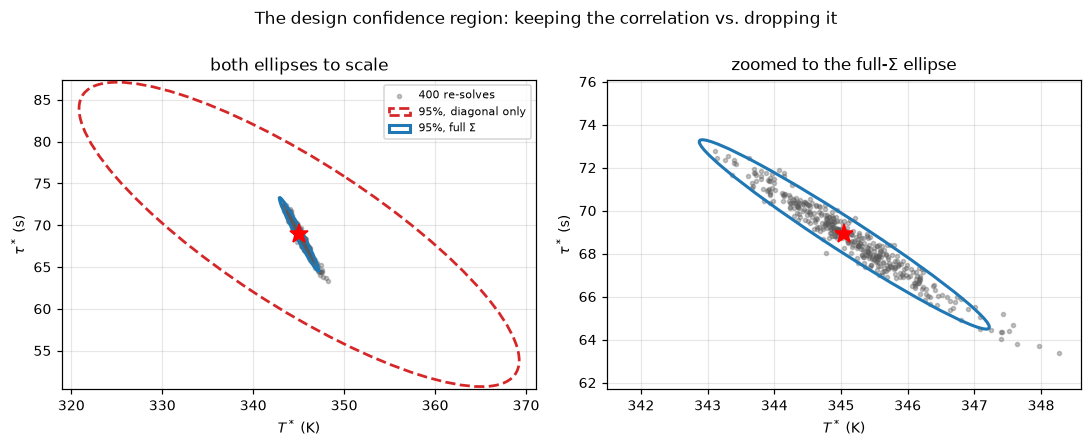

In [13]:
def ellipse_patch(mu, cov2, **kw):
    w, V = np.linalg.eigh(cov2)
    ang = np.degrees(np.arctan2(V[1, -1], V[0, -1]))
    return Ellipse(mu, 2 * 2.4477 * np.sqrt(w[-1]), 2 * 2.4477 * np.sqrt(w[0]),
                   angle=ang, **kw)

mu = np.array([T_STAR, TAU_STAR])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, zoom in zip(axes, (False, True)):
    ax.scatter(MC[:, 0], MC[:, 1], s=7, alpha=0.35, color="0.35",
               label=f"{N_MC} re-solves", zorder=3)
    ax.add_patch(ellipse_patch(mu, cov_diag, fill=False, ec="C3", lw=1.8, ls="--",
                               label="95%, diagonal only", zorder=4))
    ax.add_patch(ellipse_patch(mu, cov_full, fill=False, ec="C0", lw=2.0,
                               label=r"95%, full $\Sigma$", zorder=5))
    ax.plot(*mu, "r*", ms=13, zorder=6)
    ax.set_xlabel("$T^*$ (K)"); ax.set_ylabel(r"$\tau^*$ (s)")
    if zoom:
        s = 4 * np.sqrt([cov_full[0, 0], cov_full[1, 1]])
        ax.set_xlim(mu[0] - s[0], mu[0] + s[0]); ax.set_ylim(mu[1] - s[1], mu[1] + s[1])
        ax.set_title(r"zoomed to the full-$\Sigma$ ellipse")
    else:
        ax.set_title("both ellipses to scale"); ax.legend(fontsize=7, loc="upper right")
fig.suptitle("The design confidence region: keeping the correlation vs. dropping it", y=1.0)
fig.tight_layout(); plt.show()

The left panel is the whole argument in one picture: the dashed
diagonal-only ellipse is an enormous blob, the solid full-$\Sigma$ ellipse is
the thin sliver inside it, and the actual re-solves lie in the sliver.

The delta method lands within a Monte Carlo standard error of the empirical
spread, which is agreement rather than evidence about the linearization — at
*this* parameter spread the model is effectively linear. To see the
approximation fail you have to make it fail, by scaling $\Sigma$ by $s^2$ and
watching the error grow.

Two details make that measurement clean. **Common random numbers**: draw the
standard normals once and rescale them, so every row is the same experiment at
a different amplitude and the curve is not a random walk. And compare against
the linearization evaluated on **those same draws** rather than against
$s\sqrt{J\Sigma J^{\mathsf T}}$, so that a 400-draw sample's own few-percent
covariance error cancels instead of leaving a floor.

Two columns, because they answer different questions. The **ratio** of standard
deviations is what a practitioner cares about — how wrong is the error bar? The
**max residual** $\max_k|\Delta T^\star_k - s\,J_0^{\mathsf T}d_k|$ is the
linearization error itself, and it is the one with the clean scaling law.

In [14]:
L = np.linalg.cholesky(SIGMA)
Z = mc_rng.standard_normal((400, 4))
D = (L @ Z.T).T                        # parameter offsets, unit amplitude
lin = D @ J[0]                         # what the linearization predicts for T*

print(f"{'scale s':>9s}{'MC sd(T*)':>12s}{'linearized':>12s}{'ratio':>9s}"
      f"{'max resid':>12s}{'resid/s^2':>11s}")
for s in (8.0, 4.0, 2.0, 1.0, 0.5, 0.25):
    dT = np.array([solve_design(THETA_HAT + s * d) for d in D])[:, 0] - T_STAR
    resid = np.abs(dT - s * lin).max()
    print(f"{s:9.2f}{dT.std(ddof=1):12.4f}{s * lin.std(ddof=1):12.4f}"
          f"{dT.std(ddof=1) / (s * lin.std(ddof=1)):9.4f}{resid:12.3e}{resid / s**2:11.3f}")

  scale s   MC sd(T*)  linearized    ratio   max resid  resid/s^2


     8.00      8.1058      6.9441   1.1673   1.826e+01      0.285


     4.00      3.6742      3.4720   1.0582   7.124e+00      0.445


     2.00      1.7475      1.7360   1.0066   1.590e+00      0.397


     1.00      0.8655      0.8680   0.9971   3.633e-01      0.363


     0.50      0.4327      0.4340   0.9970   9.496e-02      0.380


     0.25      0.2166      0.2170   0.9981   2.451e-02      0.392


The last column is the point: $\mathrm{resid}/s^2$ is roughly constant as $s$
falls, so the linearization error is $O(s^2)$ exactly as an omitted second-order
term should be. That is the positive evidence that $J$ is right — a wrong $J$
leaves an $O(s)$ error, which would show as this column blowing up.

The error bar itself is more forgiving than the pointwise error. It is off by
$17\,\%$ at eight times the fitted uncertainty, and by well under a percent at
$s \le 1$. At the spread the data actually support, the delta method is not an
approximation you have to apologize for; it is exact to the order the question
is being asked at.

## 8. Which measurement would pay for itself?

$g = \mathrm df^\star/\mathrm d\theta$ is one number per parameter and needs no
$J$ at all, so uncertainty in the *objective* is much cheaper than uncertainty
in the design. It also decomposes: since $\Sigma$ is not diagonal, the additive
split of $\operatorname{Var}(f^\star)=g^{\mathsf T}\Sigma g$ is
$\sum_i g_i (\Sigma g)_i$, whose terms sum to the total and **can be negative**.

The question worth asking of that decomposition is not "which parameter is
biggest" but the counterfactual one: *if this parameter were known exactly,
what would $\mathrm{sd}(\mathrm{profit})$ become?* That is the conditional
variance — the Schur complement of $\Sigma$ on the parameters that remain. It
costs nothing to also ask it of a **pair**, which turns out to be the
interesting version.

In [15]:
contrib = g_prof * (SIGMA @ g_prof) / (g_prof @ SIGMA @ g_prof)


def sd_profit_given(idx):
    """sd(profit) if the parameters in `idx` were known exactly."""
    keep = [j for j in range(4) if j not in idx]
    S = (SIGMA[np.ix_(keep, keep)]
         - SIGMA[np.ix_(keep, idx)]
         @ np.linalg.solve(SIGMA[np.ix_(idx, idx)], SIGMA[np.ix_(idx, keep)]))
    return float(np.sqrt(g_prof[keep] @ S @ g_prof[keep]))


singles = {(i,): sd_profit_given([i]) for i in range(4)}
pairs   = {ij: sd_profit_given(list(ij)) for ij in itertools.combinations(range(4), 2)}

print(f"sd(profit) as it stands: {sd_profit_full:.4f} $/L\n")
print(f"{'':7s}{'df/dtheta':>12s}{'var share':>12s}{'sd if known':>13s}{'reduction':>11s}")
for i, n in enumerate(THETA_NAMES):
    print(f"{n:7s}{g_prof[i]:12.4f}{contrib[i]:11.1%}{singles[(i,)]:13.4f}"
          f"{1 - singles[(i,)] / sd_profit_full:10.1%}")

print(f"\npinning a pair{'':>12s}{'sd if known':>13s}{'reduction':>11s}")
for ij, v in sorted(pairs.items(), key=lambda kv: kv[1]):
    lbl = "+".join(THETA_NAMES[k] for k in ij)
    print(f"{lbl:26s}{v:13.4f}{1 - v / sd_profit_full:10.1%}")

sd(profit) as it stands: 0.2340 $/L

          df/dtheta   var share  sd if known  reduction
lnA1        21.0973     597.7%       0.2247      4.0%
E1          -7.3542    -559.8%       0.2254      3.7%
lnA2       -10.7630    -686.5%       0.2292      2.1%
E2           3.7518     748.5%       0.2283      2.5%

pinning a pair              sd if known  reduction
lnA2+E2                          0.1780     23.9%
lnA1+E1                          0.2111      9.8%
lnA1+E2                          0.2221      5.1%
E1+E2                            0.2226      4.9%
lnA1+lnA2                        0.2228      4.8%
E1+lnA2                          0.2234      4.6%


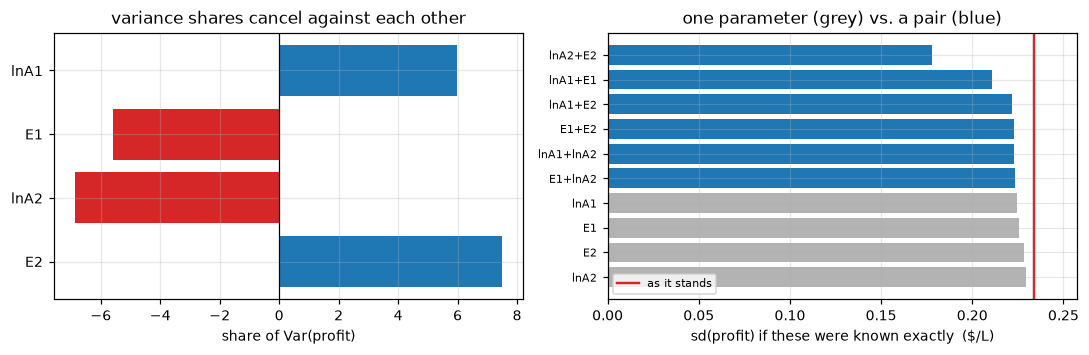

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))

ax = axes[0]
y = np.arange(4)
ax.barh(y, contrib, color=["C0" if c > 0 else "C3" for c in contrib])
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(y, THETA_NAMES); ax.invert_yaxis()
ax.set_xlabel("share of Var(profit)")
ax.set_title(r"variance shares cancel against each other")

ax = axes[1]
labels = ([THETA_NAMES[i] for (i,) in singles]
          + ["+".join(THETA_NAMES[k] for k in ij) for ij in pairs])
vals = list(singles.values()) + list(pairs.values())
order = np.argsort(vals)[::-1]
cols = ["0.7"] * 4 + ["C0"] * len(pairs)
yy = np.arange(len(vals))
ax.barh(yy, [vals[i] for i in order], color=[cols[i] for i in order])
ax.set_yticks(yy, [labels[i] for i in order], fontsize=7)
ax.axvline(sd_profit_full, color="C3", lw=1.6, label="as it stands")
ax.set_xlim(0, sd_profit_full * 1.1)
ax.set_xlabel("sd(profit) if these were known exactly  ($/L)")
ax.set_title("one parameter (grey) vs. a pair (blue)")
ax.legend(fontsize=7, loc="lower left")

fig.tight_layout(); plt.show()

The shares are $\pm 600$–$750\,\%$ of a total of 100 %. That is not a bug in
the arithmetic: the four contributions very nearly cancel, and the profit's
modest $\pm 0.23$ \$/L is what survives a near-cancellation between terms each
an order of magnitude larger. It is the section 6 lesson restated on the
objective — the variance lives in a *combination*, not in any parameter.

Which is why the counterfactual answer is **no single measurement is worth
making**. Pinning any one of the four exactly buys 2–4 % off
$\mathrm{sd}(\mathrm{profit})$; you could determine $E_2$ perfectly and barely
move the answer, because its partner $\ln A_2$ would still be free to follow it
along the compensation line. Pin the *pair* — both parameters of the waste
reaction — and the reduction is 24 %, six times what its two members buy
separately. Pairs that straddle the two reactions are worth about as little as
singletons.

The experimental recommendation that comes out of this is therefore not "measure
$E_2$ better." It is "run experiments that break the $\ln A_2/E_2$ correlation" —
which means a wider temperature range, since it is the narrow window that made
the pair inseparable in the first place. That conclusion came from $g$, $\Sigma$,
and a $2\times2$ Schur complement; no additional solve was involved.

## 9. Where the linearization stops

Everything so far assumed $x^\star(\theta)$ is differentiable. Put a safety cap
on the reactor temperature just above the unconstrained optimum —
$T \le 345.5$ K, against $T^\star = 345.05$ K — and it is not.

At the base point the cap is **inactive**, so the factorization is the same one
as before and `sens_jacobian` cheerfully returns the same nonzero
$\partial T^\star/\partial\theta$. The delta method therefore predicts the same
symmetric Gaussian, $\pm 0.89$ K. But a perturbation that pushes $T^\star$ up
runs into the cap after a fraction of a standard deviation, and from there the
design stops moving. The truth is a distribution with an atom at the bound.

POUNCE can say this from the held factor, before any re-solve.
`sens_solution_report` reports which variables the step drives across a bound and
by how far; `sens_active_set_changes` reports the fraction of the step at which
each change happens. We probe along $\pm 1$ standard deviation of the dominant
eigendirection of $\Sigma$.

In [17]:
T_CAP = 345.5
m_cap = build_design_model(THETA_HAT, T_max=T_CAP)
declare_sens_param(m_cap.lnA1, m_cap.E1, m_cap.lnA2, m_cap.E2)
SOLVER.solve(m_cap)
CAP_PARAMS = [m_cap.lnA1, m_cap.E1, m_cap.lnA2, m_cap.E2]

J_cap = np.array([[sens_jacobian(v, wrt=p) for p in CAP_PARAMS]
                  for v in (m_cap.T, m_cap.tau)])
cov_cap = J_cap @ SIGMA @ J_cap.T
print(f"base T* = {pyo.value(m_cap.T):.4f} K  (cap {T_CAP}) -- cap is inactive here")
print(f"delta method still predicts sd(T*) = {np.sqrt(cov_cap[0, 0]):.3f} K, symmetric\n")

w, V = np.linalg.eigh(SIGMA)
probe = V[:, -1] * np.sqrt(w[-1])              # one sigma along the sloppiest direction
for label, direction in (("+1 sigma", probe), ("-1 sigma", -probe)):
    pert = [(p, float(THETA_HAT[i] + direction[i])) for i, p in enumerate(CAP_PARAMS)]
    rep = sens_solution_report(m_cap, pert)
    events = sens_active_set_changes(m_cap, pert)
    crossed = {k.name: v for k, v in rep.crossed.items()}
    print(f"{label}:  crossed={crossed}")
    print(f"           active-set changes="
          f"{[(e.var.name, e.bound, e.action, round(e.fraction, 3)) for e in events]}")

base T* = 345.0499 K  (cap 345.5) -- cap is inactive here
delta method still predicts sd(T*) = 0.888 K, symmetric

+1 sigma:  crossed={'T': 0.278747036255254}
           active-set changes=[('T', 'upper', 'reaches', 0.618)]
-1 sigma:  crossed={}
           active-set changes=[]


Read that carefully. Along $+1\sigma$ the temperature **reaches its upper bound
at 62 % of the step** and overshoots the cap by 0.28 K; along $-1\sigma$ nothing
crosses at all. The response is not merely nonlinear, it is *asymmetric*, and no
single covariance ellipse can represent it. Monte Carlo confirms it, and this
is the one place in the notebook where the 400 re-solves tell you something the
one factorization could not — though the factorization told you not to trust the
ellipse, which was the part that mattered.

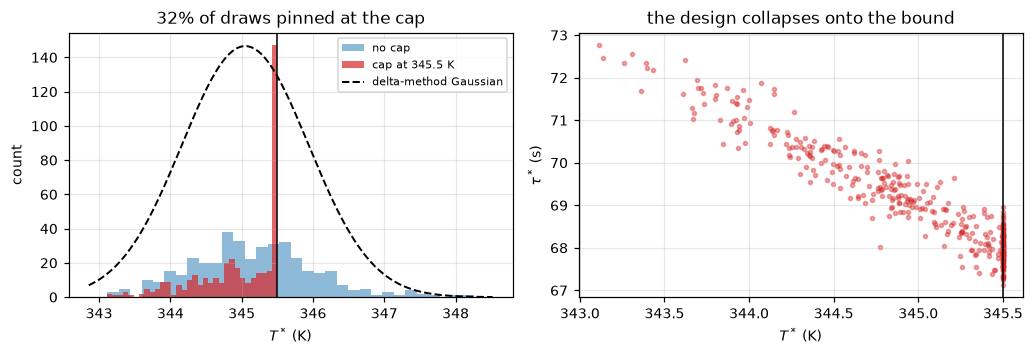

Monte Carlo sd(T*) with the cap = 0.588 K
delta method predicted           = 0.888 K
fraction of draws exactly at the cap = 32.2%


In [18]:
MC_CAP = np.array([solve_design(t, T_max=T_CAP) for t in THETA_MC])
at_cap = np.mean(MC_CAP[:, 0] > T_CAP - 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))

ax = axes[0]
ax.hist(MC[:, 0], bins=32, alpha=0.5, color="C0", label="no cap")
ax.hist(MC_CAP[:, 0], bins=32, alpha=0.7, color="C3", label=f"cap at {T_CAP} K")
xs = np.linspace(*ax.get_xlim(), 300)
gauss = np.exp(-0.5 * ((xs - pyo.value(m_cap.T)) / np.sqrt(cov_cap[0, 0]))**2)
ax.plot(xs, gauss * ax.get_ylim()[1] * 0.95, "k--", lw=1.3,
        label="delta-method Gaussian")
ax.axvline(T_CAP, color="k", lw=1.0)
ax.set_xlabel("$T^*$ (K)"); ax.set_ylabel("count")
ax.set_title(f"{at_cap:.0%} of draws pinned at the cap"); ax.legend(fontsize=7)

ax = axes[1]
ax.scatter(MC_CAP[:, 0], MC_CAP[:, 1], s=7, alpha=0.4, color="C3")
ax.axvline(T_CAP, color="k", lw=1.0)
ax.set_xlabel("$T^*$ (K)"); ax.set_ylabel(r"$\tau^*$ (s)")
ax.set_title("the design collapses onto the bound")

fig.tight_layout(); plt.show()

print(f"Monte Carlo sd(T*) with the cap = {MC_CAP[:, 0].std(ddof=1):.3f} K")
print(f"delta method predicted           = {np.sqrt(cov_cap[0, 0]):.3f} K")
print(f"fraction of draws exactly at the cap = {at_cap:.1%}")

## 10. An error bar on a shadow price

Push the cap down to 343 K so it binds at the base point. Its multiplier is
then the **shadow price of the safety limit**: the profit per litre bought by
each extra kelvin of allowable temperature — the number a debate about buying a
better cooling system actually turns on. And since the multiplier is a function
of the kinetics, it has an error bar of its own, from the same $\Sigma$.

Two API facts shape this section, and both are worth knowing before you plan
around them:

* **Multiplier sensitivities are available for equality constraints only.** A
  variable bound or an inequality has no $\mathrm d\lambda/\mathrm dp$ row to
  read. So once the cap is known to be active we write it as
  `m.T == T_cap`, which is what makes the question answerable.
* **The `dual` Suffix comes back from a declared solve too**, so one solve
  answers both halves: the multiplier from `m.dual`, its derivative from
  `sens_jacobian`. The declared path solves in process rather than exchanging a
  `.sol` file, and it used to load no result suffixes at all — an earlier draft
  of this section ran a second, ordinary solve of the same model just to read
  the number `m.dual` now holds.

Signs: Pyomo's `m.dual` holds the AMPL marginal $\mathrm df/\mathrm db$ of the
objective **as the model states it**, and `sens_jacobian` already negates the
raw row so it matches a finite difference of `m.dual` (gh#271). Our objective is
negative profit, so the profit shadow price is `-m.dual[m.cap]`.

In [19]:
T_CAP_BIND = 343.0


def build_capped(theta, T_cap=T_CAP_BIND):
    m = build_design_model(theta, T_max=400.0)        # bound well clear of the cap
    m.cap = pyo.Constraint(expr=m.T == T_cap)
    return m


m_sh = build_capped(THETA_HAT)
m_sh.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
declare_sens_param(m_sh.lnA1, m_sh.E1, m_sh.lnA2, m_sh.E2)
SOLVER.solve(m_sh)
SH_PARAMS = [m_sh.lnA1, m_sh.E1, m_sh.lnA2, m_sh.E2]

# the multiplier itself, from the dual Suffix of that one solve ...
shadow = -m_sh.dual[m_sh.cap]                         # $/L per K of cap relaxation
# ... and its derivative, from the KKT factor the same solve held
d_shadow = -np.array([sens_jacobian(m_sh.cap, wrt=p) for p in SH_PARAMS])
sd_shadow = float(np.sqrt(d_shadow @ SIGMA @ d_shadow))

print(f"profit at the 343 K cap      {-pyo.value(m_sh.obj):.4f} $/L")
print(f"shadow price of the cap      {shadow:+.4f} $/L per K")
print(f"          its uncertainty    {sd_shadow:.4f} $/L per K"
      f"   ({sd_shadow / abs(shadow):.0%} relative)\n")
print(f"{'':7s}{'d(shadow)/dtheta':>18s}")
for n, v in zip(THETA_NAMES, d_shadow):
    print(f"{n:7s}{v:18.5f}")

profit at the 343 K cap      49.3461 $/L
shadow price of the cap      +0.0541 $/L per K
          its uncertainty    0.0212 $/L per K   (39% relative)

         d(shadow)/dtheta
lnA1             -0.05514
E1                0.04100
lnA2             -0.25765
E2                0.07988


The design was pinned to about 0.3 % ($345.0\pm0.9$ K); the shadow price of the
safety limit is known to about 40 %. That is not a contradiction, it is the
ordinary state of affairs: a multiplier is a derivative of the optimum, so it
depends on curvature, and curvature is a weaker function of the data than
position is. If a capital decision hinges on this number, the error bar is the
part of the answer that decides whether the decision is even resolvable — and
it came from the same $\Sigma$ and one extra backsolve per parameter.

## Summary

* `sens_covariance` gives $\Sigma_\theta$ from the fit; `sens_jacobian` gives
  $J=\partial x^\star/\partial\theta$ and the total $g=\mathrm df^\star/\mathrm
  d\theta$ from the design solve. $J\Sigma J^{\mathsf T}$ turns parameter
  uncertainty into a confidence region on a **design**. Every derivative is an
  exact backsolve against a held KKT factor; the 400-solve Monte Carlo in
  section 7 is a check on the method, not part of it.
* **Keep the off-diagonal.** Arrhenius $\ln A$ and $E$ correlate above 0.999,
  and propagating standard errors alone inflated $\mathrm{sd}(T^\star)$ by
  $11\times$ and $\mathrm{sd}(\mathrm{profit})$ by $57\times$. Reporting
  parameters as independent $\pm$ values discards the best-determined thing the
  experiment measured.
* **The delta method is first order**, and at this spread that costs nothing —
  it agreed with 400 re-solves to within a Monte Carlo standard error. Inflating
  $\Sigma$ shows the approximation degrading and shrinking it shows the ratio
  returning to 1, which is how you tell curvature from a wrong $J$.
* **The variance lives in a combination, and so does the fix.** The four
  contributions to $\operatorname{Var}(\mathrm{profit})$ are each 5.6–7.5$\times$
  the total and nearly cancel. Knowing any single parameter exactly buys 2–4 %;
  knowing the waste reaction's *pair* buys 24 %. A conditional-variance
  calculation on $g$ and $\Sigma$ says which experiment to run next, with no
  further solves.
* **An active constraint ends the linearization.** When the cap binds for some
  parameter draws and not others the true distribution has an atom at the bound
  and no ellipse describes it. `sens_solution_report` and
  `sens_active_set_changes` detect that from the base factorization; here the
  step crossed at 62 % of one standard deviation in one direction and never in
  the other.
* **Multiplier sensitivities are equality-only**, which is what lets a *known
  active* cap carry an error bar on its shadow price.

Related: notebook 26 (covariance and identifiability), 31 (the information
matrix), 32 (`of=` blocks and holding the factor), 36 (active-set-aware
sensitivity in closed loop), and `docs/src/sensitivity.md`.

In [20]:
for m in (m_fit, m_des, m_cap, m_sh):
    sens_release_kkt(m)
print("KKT factorizations released")

KKT factorizations released
